# Импорты

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests

import backtrader as bt
from dateutil.relativedelta import relativedelta

# Датафид

In [2]:
class PandasOHLCV(bt.feeds.PandasData):
    """
    Требуемые колонки в DataFrame:
    open, high, low, close, volume
    Индекс: datetime
    """
    params = (
        ("datetime", None),
        ("open", "open"),
        ("high", "high"),
        ("low", "low"),
        ("close", "close"),
        ("volume", "volume"),
        ("openinterest", -1),
    )

# Кастомные индикаторы

In [3]:
class ChaikinMoneyFlow(bt.Indicator):
    lines = ("cmf",)
    params = (("period", 20),)

    def __init__(self):
        high = self.data.high
        low = self.data.low
        close = self.data.close
        volume = self.data.volume

        # Money Flow Multiplier
        denom = (high - low)
        mfm = bt.If(denom != 0, ((close - low) - (high - close)) / denom, 0.0)

        mfv = mfm * volume

        sum_mfv = bt.indicators.SumN(mfv, period=self.p.period)
        sum_vol = bt.indicators.SumN(volume, period=self.p.period)

        self.lines.cmf = bt.If(sum_vol != 0, sum_mfv / sum_vol, 0.0)

# Analyzer для списка сделок

In [41]:
class TradeListAnalyzer(bt.Analyzer):
    def start(self):
        self.trades = []

    def notify_trade(self, trade):
        if not trade.isclosed:
            return

        dt_open = bt.num2date(trade.dtopen)
        dt_close = bt.num2date(trade.dtclose)

        price_out = trade.price + (trade.pnl / trade.size if trade.size else 0.0)

        self.trades.append({
            "entry_time": pd.Timestamp(dt_open),
            "exit_time": pd.Timestamp(dt_close),
            "size": trade.size,
            "price_in": trade.price,
            "price_out": price_out,
            "pnl_gross": trade.pnl,
            "pnl_net": trade.pnlcomm,
            "barlen": trade.barlen,
        })

    def get_analysis(self):
        return self.trades

# Стратегия BTCMacdRsiStrategy

In [42]:
class BTCMacdRsiStrategy(bt.Strategy):
    params = dict(
        # MACD
        macd_fast=12,
        macd_slow=26,
        macd_signal=9,

        # RSI
        rsi_period=14,
        rsi_entry_level=45,   # вход, когда RSI возвращается выше уровня
        rsi_exit_level=40,    # аварийный выход, если RSI снова слабеет

        # ATR / risk
        atr_period=14,
        risk_per_trade=0.01,
        atr_stop_mult=1.5,
        rr_target=1.5,
        max_bars_in_trade=72,

        debug=False,
    )

    def log(self, txt):
        if self.p.debug:
            dt = self.datas[0].datetime.datetime(0)
            print(f"{dt} | {txt}")

    def __init__(self):
        data = self.datas[0]

        self.order = None
        self.entry_bar = None
        self.entry_price = None
        self.stop_price = None
        self.take_price = None

        # MACD
        self.macd = bt.indicators.MACD(
            data.close,
            period_me1=self.p.macd_fast,
            period_me2=self.p.macd_slow,
            period_signal=self.p.macd_signal,
        )

        # RSI
        self.rsi = bt.indicators.RSI(data.close, period=self.p.rsi_period)

        # ATR
        self.atr = bt.indicators.ATR(data, period=self.p.atr_period)

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:
            if order.isbuy():
                self.log(f"BUY EXECUTED | price={order.executed.price:.2f}, size={order.executed.size:.6f}")
            elif order.issell():
                self.log(f"SELL EXECUTED | price={order.executed.price:.2f}, size={order.executed.size:.6f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log(f"ORDER FAILED | status={order.getstatusname()}")

        self.order = None

    def notify_trade(self, trade):
        if trade.isclosed:
            self.log(f"TRADE CLOSED | gross={trade.pnl:.2f}, net={trade.pnlcomm:.2f}")

    def _long_signal(self):
        # 1. MACD как фильтр направления
        macd_bullish = self.macd.macd[0] > self.macd.signal[0]

        # 2. RSI как триггер входа:
        # RSI сейчас выше entry_level, а на прошлом баре был ниже/равен
        rsi_reclaim = (
            (self.rsi[0] > self.p.rsi_entry_level) and
            (self.rsi[-1] <= self.p.rsi_entry_level)
        )

        return macd_bullish and rsi_reclaim

    def _exit_signal(self):
        # MACD перестал быть bullish
        macd_turned_down = self.macd.macd[0] < self.macd.signal[0]

        # RSI снова ослаб
        rsi_weak = self.rsi[0] < self.p.rsi_exit_level

        return macd_turned_down or rsi_weak

    def _calc_position_size(self, entry_price, stop_price):
        cash = self.broker.getcash()
        risk_amount = cash * self.p.risk_per_trade
        stop_distance = entry_price - stop_price

        if stop_distance <= 0:
            return 0.0

        size = risk_amount / stop_distance
        max_affordable = cash / entry_price if entry_price > 0 else 0.0
        size = min(size, max_affordable)

        if not np.isfinite(size) or size <= 0:
            return 0.0

        return size

    def next(self):
        if self.order:
            return

        close = self.data.close[0]

        # Exit logic
        if self.position:
            bars_held = len(self) - self.entry_bar if self.entry_bar is not None else 0

            if self.data.low[0] <= self.stop_price:
                self.log(f"EXIT STOP | stop={self.stop_price:.2f}")
                self.order = self.close()
                return

            if self.data.high[0] >= self.take_price:
                self.log(f"EXIT TAKE | take={self.take_price:.2f}")
                self.order = self.close()
                return

            if self._exit_signal():
                self.log("EXIT SIGNAL")
                self.order = self.close()
                return

            if bars_held >= self.p.max_bars_in_trade:
                self.log("EXIT TIMEOUT")
                self.order = self.close()
                return

        # Entry logic
        if not self.position and self._long_signal():
            entry_price = close
            stop_price = entry_price - self.p.atr_stop_mult * self.atr[0]

            if not np.isfinite(stop_price) or stop_price >= entry_price:
                return

            size = self._calc_position_size(entry_price, stop_price)
            if size <= 0:
                return

            take_price = entry_price + self.p.rr_target * (entry_price - stop_price)

            self.entry_price = entry_price
            self.stop_price = stop_price
            self.take_price = take_price
            self.entry_bar = len(self)

            self.log(
                f"ENTRY LONG | entry={entry_price:.2f}, stop={stop_price:.2f}, "
                f"take={take_price:.2f}, size={size:.6f}"
            )
            self.order = self.buy(size=size)

# Функция одиночного прогона бэктеста

In [43]:
def run_backtest_bt(
    df: pd.DataFrame,
    strategy_cls=BTCMacdRsiStrategy,
    strategy_params=None,
    initial_cash=10_000.0,
    commission=0.0004,
    slippage_perc=0.0002,
    plot=False,
):
    if strategy_params is None:
        strategy_params = {}

    data = df.copy()
    required_cols = {"open", "high", "low", "close", "volume"}
    missing = required_cols - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be DatetimeIndex")

    data = data.sort_index()

    cerebro = bt.Cerebro(stdstats=False)
    cerebro.broker.setcash(initial_cash)
    cerebro.broker.setcommission(commission=commission)
    cerebro.broker.set_slippage_perc(perc=slippage_perc)

    feed = PandasOHLCV(dataname=data)
    cerebro.adddata(feed)

    cerebro.addstrategy(strategy_cls, **strategy_params)

    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name="timereturn")
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="tradeanalyzer")
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name="sharpe", timeframe=bt.TimeFrame.Days, annualize=True)
    cerebro.addanalyzer(TradeListAnalyzer, _name="tradelist")

    results = cerebro.run()
    strat = results[0]

    final_value = cerebro.broker.getvalue()
    pnl = final_value - initial_cash

    # -------- helper ----------
    def safe_float(x, default=0.0):
        if x is None:
            return float(default)
        try:
            x = float(x)
        except (TypeError, ValueError):
            return float(default)
        if not np.isfinite(x):
            return float(default)
        return x

    # Equity curve
    rets = strat.analyzers.timereturn.get_analysis()
    returns_series = pd.Series(rets, dtype=float)
    if len(returns_series) > 0:
        equity_curve = (1 + returns_series).cumprod() * initial_cash
        equity_df = pd.DataFrame({"equity": equity_curve})
        equity_df.index = pd.to_datetime(equity_df.index)
    else:
        equity_df = pd.DataFrame(columns=["equity"])

    # Trades
    trades = strat.analyzers.tradelist.get_analysis()
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()

    trade_an = strat.analyzers.tradeanalyzer.get_analysis()
    dd_an = strat.analyzers.drawdown.get_analysis()
    sharpe_an = strat.analyzers.sharpe.get_analysis()

    total_trades = trade_an.get("total", {}).get("closed", 0) if isinstance(trade_an, dict) else 0
    won_total = trade_an.get("won", {}).get("total", 0) if isinstance(trade_an, dict) else 0

    gross_profit = trade_an.get("won", {}).get("pnl", {}).get("total", 0.0) if isinstance(trade_an, dict) else 0.0
    gross_loss_abs = abs(trade_an.get("lost", {}).get("pnl", {}).get("total", 0.0)) if isinstance(trade_an, dict) else 0.0
    profit_factor = gross_profit / gross_loss_abs if gross_loss_abs > 0 else np.nan

    sharpe_value = sharpe_an.get("sharperatio", 0.0) if isinstance(sharpe_an, dict) else 0.0
    max_dd_value = dd_an.get("max", {}).get("drawdown", 0.0) if isinstance(dd_an, dict) else 0.0

    metrics = {
        "initial_cash": safe_float(initial_cash),
        "final_value": safe_float(final_value),
        "net_profit": safe_float(pnl),
        "total_return_pct": safe_float((final_value / initial_cash - 1) * 100),
        "max_drawdown_pct": safe_float(max_dd_value),
        "n_trades": int(total_trades),
        "win_rate_pct": safe_float((won_total / total_trades) * 100 if total_trades > 0 else 0.0),
        "profit_factor": safe_float(profit_factor, default=0.0),
        "sharpe": safe_float(sharpe_value, default=0.0),
    }

    if plot:
        cerebro.plot(style="candlestick")

    return {
        "metrics": metrics,
        "trades_df": trades_df,
        "equity_df": equity_df,
        "strategy": strat,
        "cerebro": cerebro,
    }

# Дефолтные параметры стратегии

In [44]:
DEFAULT_PARAMS = dict(
    macd_fast=12,
    macd_slow=26,
    macd_signal=9,

    rsi_period=14,
    rsi_entry_level=45,
    rsi_exit_level=40,

    atr_period=14,
    risk_per_trade=0.01,
    atr_stop_mult=1.5,
    rr_target=1.5,
    max_bars_in_trade=72,

    debug=False,
)

# Загрузка и подготовка данных

In [32]:
def load_binance_klines(
    symbol: str = "BTCUSDT",
    interval: str = "5m",
    limit_total: int = 10_000,
    drop_timezone: bool = True,
) -> pd.DataFrame:
    """
    Загружает историю свечей Binance пачками по 1000, двигаясь назад во времени.

    Возвращает DataFrame:
    - index: datetime
    - columns: open, high, low, close, volume

    Parameters
    ----------
    symbol : str
        Торговый символ Binance, например BTCUSDT.
    interval : str
        Интервал свечей, например 5m, 15m, 1h.
    limit_total : int
        Сколько свечей максимум загрузить.
    drop_timezone : bool
        Если True, убирает timezone из индекса.
        Для Backtrader обычно так удобнее.
    """
    url = "https://api.binance.com/api/v3/klines"
    per_request = 1000
    all_klines = []
    end_time = None

    with requests.Session() as session:
        session.trust_env = False

        while len(all_klines) < limit_total:
            params = {
                "symbol": symbol,
                "interval": interval,
                "limit": per_request,
            }

            if end_time is not None:
                params["endTime"] = end_time - 1

            resp = session.get(url, params=params, timeout=20)
            resp.raise_for_status()
            klines = resp.json()

            if not klines:
                break

            all_klines = klines + all_klines
            end_time = klines[0][0]

            if len(klines) < per_request:
                break

            time.sleep(0.1)

    if not all_klines:
        raise ValueError("Binance returned no klines.")

    all_klines = all_klines[-limit_total:]

    df = pd.DataFrame(
        all_klines,
        columns=[
            "open_time", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
        ]
    )

    # Числовые колонки
    numeric_cols = ["open", "high", "low", "close", "volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Дата
    df["datetime"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)

    # Оставляем только то, что нужно стратегии
    df = df[["datetime", "open", "high", "low", "close", "volume"]].copy()

    # Сортировка, удаление дублей, удаление пропусков
    df = df.sort_values("datetime")
    df = df.drop_duplicates(subset=["datetime"])
    df = df.dropna(subset=["open", "high", "low", "close", "volume"])

    # Индекс
    df = df.set_index("datetime")

    # Для Backtrader обычно удобнее naive datetime index
    if drop_timezone:
        df.index = df.index.tz_convert(None)

    # Финальная сортировка на всякий случай
    df = df.sort_index()

    # Базовая проверка
    if df.empty:
        raise ValueError("Prepared DataFrame is empty.")

    expected_cols = ["open", "high", "low", "close", "volume"]
    if list(df.columns) != expected_cols:
        raise ValueError(f"Unexpected columns: {df.columns.tolist()}")

    return df


# ====== Параметры загрузки ======
SYMBOL = "BTCUSDT"
INTERVAL = "15m"
LIMIT_TOTAL = 50_000


# ====== Загрузка ======
df = load_binance_klines(
    symbol=SYMBOL,
    interval=INTERVAL,
    limit_total=LIMIT_TOTAL,
    drop_timezone=True,
)


# ====== Проверка ======
print("Data loaded successfully")
print(f"Symbol: {SYMBOL}")
print(f"Interval: {INTERVAL}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"Index type: {type(df.index)}")
print(f"Timezone: {df.index.tz}")
print(f"Date range: {df.index.min()} -> {df.index.max()}")
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicated index:", df.index.duplicated().sum())

display(df.head())
display(df.tail())

Data loaded successfully
Symbol: BTCUSDT
Interval: 15m
Rows: 50,000
Columns: ['open', 'high', 'low', 'close', 'volume']
Index type: <class 'pandas.DatetimeIndex'>
Timezone: None
Date range: 2024-11-09 22:00:00 -> 2026-04-14 17:45:00

Missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Duplicated index: 0


,open,high,low,close,volume
datetime,,,,,
2024-11-09 22:00:00,76451.61,76459.91,76365.25,76387.27,62.29777
2024-11-09 22:15:00,76387.28,76462.87,76375.78,76462.86,63.00554
2024-11-09 22:30:00,76462.86,76518.61,76441.18,76518.61,147.75938
2024-11-09 22:45:00,76518.60,76606.34,76365.95,76519.90,337.56888
2024-11-09 23:00:00,76519.90,76750.90,76474.00,76618.86,402.46368


,open,high,low,close,volume
datetime,,,,,
2026-04-14 16:45:00,75208.50,75233.07,74527.02,74652.20,414.16424
2026-04-14 17:00:00,74652.20,74821.52,74580.64,74793.84,229.31830
2026-04-14 17:15:00,74793.84,74948.78,74632.22,74632.23,168.78122
2026-04-14 17:30:00,74632.23,74689.99,74244.63,74550.05,377.90961
2026-04-14 17:45:00,74550.05,74674.18,74544.00,74650.01,113.92949


# Быстрый одиночный прогон

In [45]:
result = run_backtest_bt(
    df=df,
    strategy_cls=BTCMacdRsiStrategy,
    strategy_params=DEFAULT_PARAMS,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    plot=False,
)

print(result["metrics"])
result["trades_df"].tail()

{'initial_cash': 10000.0, 'final_value': 9927.129988518387, 'net_profit': -72.87001148161289, 'total_return_pct': -0.7287001148161276, 'max_drawdown_pct': 6.76948797253221, 'n_trades': 63, 'win_rate_pct': 39.682539682539684, 'profit_factor': 0.9752917909208942, 'sharpe': -0.22027065901704676}


,entry_time,exit_time,size,price_in,price_out,pnl_gross,pnl_net,barlen
58,2026-02-05 14:30:00,2026-02-05 15:00:00,0.0,70143.315858,70143.315858,-90.131973,-96.817624,2
59,2026-02-06 01:00:00,2026-02-06 06:00:00,0.0,63522.101880,63522.101880,143.628504,141.030307,20
60,2026-02-07 12:15:00,2026-02-07 12:30:00,0.0,68863.429932,68863.429932,58.455671,51.297866,1
61,2026-02-09 15:45:00,2026-02-09 17:45:00,0.0,69556.198458,69556.198458,161.256286,154.199199,8
62,2026-03-03 15:45:00,2026-03-03 16:15:00,0.0,67542.715842,67542.715842,129.732740,122.041346,2


# График equity curve

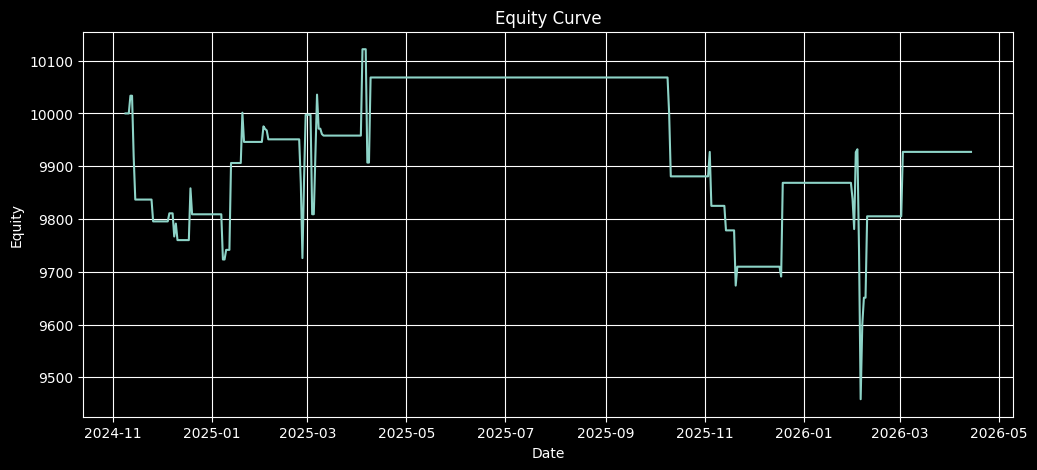

In [46]:
eq = result["equity_df"]

if not eq.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(eq.index, eq["equity"])
    plt.title("Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

# Optuna objective

In [47]:
def make_optuna_objective_bt(
    df: pd.DataFrame,
    initial_cash=10_000.0,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades=5,
):
    def objective(trial):
        params = dict(
            macd_fast=trial.suggest_int("macd_fast", 8, 16),
            macd_slow=trial.suggest_int("macd_slow", 20, 34),
            macd_signal=trial.suggest_int("macd_signal", 5, 12),

            rsi_period=trial.suggest_int("rsi_period", 7, 21),
            rsi_entry_level=trial.suggest_int("rsi_entry_level", 40, 55),
            rsi_exit_level=trial.suggest_int("rsi_exit_level", 35, 50),

            atr_period=trial.suggest_int("atr_period", 7, 21),

            risk_per_trade=0.01,
            atr_stop_mult=trial.suggest_float("atr_stop_mult", 1.0, 3.0),
            rr_target=trial.suggest_float("rr_target", 1.0, 2.5),
            max_bars_in_trade=trial.suggest_int("max_bars_in_trade", 24, 120),

            debug=False,
        )

        if params["macd_fast"] >= params["macd_slow"]:
            return -1e9
        if params["rsi_exit_level"] >= params["rsi_entry_level"]:
            return -1e9

        try:
            result = run_backtest_bt(
                df=df,
                strategy_cls=BTCMacdRsiStrategy,
                strategy_params=params,
                initial_cash=initial_cash,
                commission=commission,
                slippage_perc=slippage_perc,
                plot=False,
            )
            metrics = result["metrics"]
        except Exception as e:
            print("Trial failed:", e)
            return -1e9

        n_trades = metrics["n_trades"]
        total_return = metrics["total_return_pct"]
        max_dd = abs(metrics["max_drawdown_pct"])
        pf = metrics["profit_factor"]
        sharpe = metrics["sharpe"]

        trade_penalty = max(0, min_trades - n_trades) * 10

        score = (
            total_return
            + min(pf, 3.0) * 10.0
            + (0.0 if not np.isfinite(sharpe) else sharpe) * 5.0
            - max_dd
            - trade_penalty
        )

        return score

    return objective

# Запуск Optuna

In [48]:
import optuna

objective = make_optuna_objective_bt(
    df=df,
    initial_cash=100_000,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades=1,
)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-14 20:55:27,933] A new study created in memory with name: no-name-41293743-eea8-4c15-b6fe-c0b06554df1a
[I 2026-04-14 20:55:32,873] Trial 0 finished with value: -22.924281353995525 and parameters: {'macd_fast': 13, 'macd_slow': 22, 'macd_signal': 6, 'rsi_period': 7, 'rsi_entry_level': 55, 'rsi_exit_level': 36, 'atr_period': 16, 'atr_stop_mult': 1.8106027829407634, 'rr_target': 2.0804521421422475, 'max_bars_in_trade': 107}. Best is trial 0 with value: -22.924281353995525.
[I 2026-04-14 20:55:32,875] Trial 1 finished with value: -1000000000.0 and parameters: {'macd_fast': 11, 'macd_slow': 25, 'macd_signal': 10, 'rsi_period': 13, 'rsi_entry_level': 47, 'rsi_exit_level': 48, 'atr_period': 9, 'atr_stop_mult': 2.673009433923183, 'rr_target': 2.128667584188954, 'max_bars_in_trade': 66}. Best is trial 0 with value: -22.924281353995525.
[I 2026-04-14 20:55:32,876] Trial 2 finished with value: -1000000000.0 and parameters: {'macd_fast': 9, 'macd_slow': 23, 'macd_signal': 9, 'rsi_period

Best value: 2.25582536952278
Best params: {'macd_fast': 12, 'macd_slow': 33, 'macd_signal': 7, 'rsi_period': 14, 'rsi_entry_level': 52, 'rsi_exit_level': 43, 'atr_period': 16, 'atr_stop_mult': 2.045946062624626, 'rr_target': 1.9075830212569347, 'max_bars_in_trade': 103}


# Прогон лучших параметров после Optuna

In [49]:
best_params = study.best_params.copy()
best_params["debug"] = False

best_result = run_backtest_bt(
    df=df,
    strategy_params=best_params,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    plot=False,
)

print(best_result["metrics"])
best_result["trades_df"].tail()

{'initial_cash': 10000.0, 'final_value': 10263.62280253778, 'net_profit': 263.62280253778044, 'total_return_pct': 2.636228025377796, 'max_drawdown_pct': 11.188363552156487, 'n_trades': 148, 'win_rate_pct': 43.24324324324324, 'profit_factor': 1.0443594844887794, 'sharpe': 0.07287321028271175}


,entry_time,exit_time,size,price_in,price_out,pnl_gross,pnl_net,barlen
143,2026-03-12 16:45:00,2026-03-12 18:30:00,0.0,70395.576300,70395.576300,-49.244080,-56.337653,7
144,2026-03-19 18:00:00,2026-03-19 22:45:00,0.0,69868.120830,69868.120830,23.524094,16.393274,19
145,2026-03-30 00:30:00,2026-03-30 06:30:00,0.0,66587.524842,66587.524842,104.887923,96.965463,24
146,2026-03-31 15:15:00,2026-03-31 16:00:00,0.0,67255.158342,67255.158342,-71.739132,-79.050274,3
147,2026-03-31 16:30:00,2026-03-31 17:15:00,0.0,67109.679252,67109.679252,187.968049,180.308800,3


# Вспомогательные функции для WFA

In [50]:
def slice_df_by_date(df: pd.DataFrame, start, end):
    return df.loc[(df.index >= pd.Timestamp(start)) & (df.index < pd.Timestamp(end))].copy()


def generate_wfa_windows(
    df: pd.DataFrame,
    train_months=12,
    test_months=3,
    step_months=3,
    anchored=False,
):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be DatetimeIndex")

    start_date = df.index.min().normalize()
    end_date = df.index.max().normalize()

    windows = []
    cursor = start_date + relativedelta(months=train_months)

    while True:
        test_start = cursor
        test_end = test_start + relativedelta(months=test_months)

        if test_end > end_date:
            break

        if anchored:
            train_start = start_date
        else:
            train_start = test_start - relativedelta(months=train_months)

        train_end = test_start

        train_df = slice_df_by_date(df, train_start, train_end)
        test_df = slice_df_by_date(df, test_start, test_end)

        if len(train_df) > 0 and len(test_df) > 0:
            windows.append({
                "train_start": train_start,
                "train_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
                "n_train": len(train_df),
                "n_test": len(test_df),
            })

        cursor = cursor + relativedelta(months=step_months)

    return windows

# Основной WFA runner

In [51]:
def run_walk_forward_analysis(
    df: pd.DataFrame,
    train_months=12,
    test_months=3,
    step_months=3,
    anchored=False,
    n_trials=50,
    initial_cash=10_000.0,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades_train=20,
    study_factory=None,
    verbose=True,
):
    import optuna

    windows = generate_wfa_windows(
        df=df,
        train_months=train_months,
        test_months=test_months,
        step_months=step_months,
        anchored=anchored,
    )

    all_results = []
    oos_equity_parts = []
    all_oos_trades = []

    for i, w in enumerate(windows, start=1):
        train_df = slice_df_by_date(df, w["train_start"], w["train_end"])
        test_df = slice_df_by_date(df, w["test_start"], w["test_end"])

        if verbose:
            print(
                f"\nWFA window {i}/{len(windows)} | "
                f"TRAIN: {w['train_start'].date()} -> {w['train_end'].date()} | "
                f"TEST: {w['test_start'].date()} -> {w['test_end'].date()}"
            )

        objective = make_optuna_objective_bt(
            df=train_df,
            initial_cash=initial_cash,
            commission=commission,
            slippage_perc=slippage_perc,
            min_trades=min_trades_train,
        )

        study = study_factory() if study_factory is not None else optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        best_params = study.best_params.copy()
        best_params["debug"] = False

        is_result = run_backtest_bt(
            df=train_df,
            strategy_params=best_params,
            initial_cash=initial_cash,
            commission=commission,
            slippage_perc=slippage_perc,
            plot=False,
        )

        oos_result = run_backtest_bt(
            df=test_df,
            strategy_params=best_params,
            initial_cash=initial_cash,
            commission=commission,
            slippage_perc=slippage_perc,
            plot=False,
        )

        is_metrics = is_result["metrics"]
        oos_metrics = oos_result["metrics"]

        row = {
            "window_id": i,
            "train_start": w["train_start"],
            "train_end": w["train_end"],
            "test_start": w["test_start"],
            "test_end": w["test_end"],

            "is_return_pct": is_metrics["total_return_pct"],
            "is_max_dd_pct": is_metrics["max_drawdown_pct"],
            "is_n_trades": is_metrics["n_trades"],
            "is_pf": is_metrics["profit_factor"],
            "is_sharpe": is_metrics["sharpe"],

            "oos_return_pct": oos_metrics["total_return_pct"],
            "oos_max_dd_pct": oos_metrics["max_drawdown_pct"],
            "oos_n_trades": oos_metrics["n_trades"],
            "oos_pf": oos_metrics["profit_factor"],
            "oos_sharpe": oos_metrics["sharpe"],

            "best_value": study.best_value,
            "best_params": best_params,
        }
        all_results.append(row)

        oos_trades = oos_result["trades_df"].copy()
        if not oos_trades.empty:
            oos_trades["window_id"] = i
            all_oos_trades.append(oos_trades)

        oos_eq = oos_result["equity_df"].copy()
        if not oos_eq.empty:
            oos_eq = oos_eq.rename(columns={"equity": f"equity_window_{i}"})
            oos_equity_parts.append((i, oos_eq))

        if verbose:
            print(
                f"  IS  | return={is_metrics['total_return_pct']:.2f}% | dd={is_metrics['max_drawdown_pct']:.2f}% | "
                f"trades={is_metrics['n_trades']} | pf={is_metrics['profit_factor']:.2f}"
            )
            print(
                f"  OOS | return={oos_metrics['total_return_pct']:.2f}% | dd={oos_metrics['max_drawdown_pct']:.2f}% | "
                f"trades={oos_metrics['n_trades']} | pf={oos_metrics['profit_factor']:.2f}"
            )

    results_df = pd.DataFrame(all_results)

    stitched_oos = []
    current_capital = initial_cash

    for i, eq_df in oos_equity_parts:
        col = f"equity_window_{i}"
        temp = eq_df.copy().sort_index()

        base = temp[col].iloc[0]
        if base <= 0:
            continue

        scaled = temp[col] / base * current_capital
        current_capital = float(scaled.iloc[-1])

        stitched_oos.append(pd.DataFrame({"equity": scaled}))

    if stitched_oos:
        stitched_oos_equity = pd.concat(stitched_oos).sort_index()
        stitched_oos_equity = stitched_oos_equity[~stitched_oos_equity.index.duplicated(keep="last")]
    else:
        stitched_oos_equity = pd.DataFrame(columns=["equity"])

    if all_oos_trades:
        all_oos_trades_df = pd.concat(all_oos_trades, ignore_index=True)
    else:
        all_oos_trades_df = pd.DataFrame()

    if not stitched_oos_equity.empty:
        peak = stitched_oos_equity["equity"].cummax()
        dd = stitched_oos_equity["equity"] / peak - 1
        stitched_return_pct = (stitched_oos_equity["equity"].iloc[-1] / initial_cash - 1) * 100
        stitched_max_dd_pct = dd.min() * 100
    else:
        stitched_return_pct = 0.0
        stitched_max_dd_pct = 0.0

    summary = {
        "n_windows": len(results_df),
        "avg_is_return_pct": float(results_df["is_return_pct"].mean()) if not results_df.empty else 0.0,
        "avg_oos_return_pct": float(results_df["oos_return_pct"].mean()) if not results_df.empty else 0.0,
        "median_oos_return_pct": float(results_df["oos_return_pct"].median()) if not results_df.empty else 0.0,
        "avg_oos_pf": float(results_df["oos_pf"].replace([np.inf, -np.inf], np.nan).mean()) if not results_df.empty else 0.0,
        "stitched_oos_return_pct": float(stitched_return_pct),
        "stitched_oos_max_dd_pct": float(stitched_max_dd_pct),
    }

    return {
        "windows_df": results_df,
        "stitched_oos_equity": stitched_oos_equity,
        "all_oos_trades_df": all_oos_trades_df,
        "summary": summary,
    }

# Запуск WFA

In [ ]:
wfa_result = run_walk_forward_analysis(
    df=df,
    train_months=5,
    test_months=1,
    step_months=1,
    anchored=False,
    n_trials=100,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades_train=3,
    verbose=True,
)

print(wfa_result["summary"])
wfa_result["windows_df"][[
    "window_id",
    "train_start", "train_end",
    "test_start", "test_end",
    "is_return_pct", "oos_return_pct",
    "is_pf", "oos_pf",
    "is_n_trades", "oos_n_trades"
]]

[I 2026-04-14 21:05:18,309] A new study created in memory with name: no-name-c879b44d-e6e8-4fe5-8869-641be2d68742



WFA window 1/12 | TRAIN: 2024-11-09 -> 2025-04-09 | TEST: 2025-04-09 -> 2025-05-09


[I 2026-04-14 21:05:19,777] Trial 0 finished with value: -12.886682616516474 and parameters: {'macd_fast': 8, 'macd_slow': 30, 'macd_signal': 11, 'rsi_period': 9, 'rsi_entry_level': 53, 'rsi_exit_level': 43, 'atr_period': 18, 'atr_stop_mult': 2.077920692263098, 'rr_target': 2.08547757481153, 'max_bars_in_trade': 57}. Best is trial 0 with value: -12.886682616516474.
[I 2026-04-14 21:05:21,161] Trial 1 finished with value: -4.2417828965459075 and parameters: {'macd_fast': 9, 'macd_slow': 20, 'macd_signal': 6, 'rsi_period': 7, 'rsi_entry_level': 43, 'rsi_exit_level': 38, 'atr_period': 13, 'atr_stop_mult': 1.2248423937436692, 'rr_target': 2.2041241773226408, 'max_bars_in_trade': 83}. Best is trial 1 with value: -4.2417828965459075.
[I 2026-04-14 21:05:21,163] Trial 2 finished with value: -1000000000.0 and parameters: {'macd_fast': 9, 'macd_slow': 23, 'macd_signal': 8, 'rsi_period': 7, 'rsi_entry_level': 46, 'rsi_exit_level': 48, 'atr_period': 11, 'atr_stop_mult': 1.0176312338124724, 'rr_ta

# График stitched OOS equity

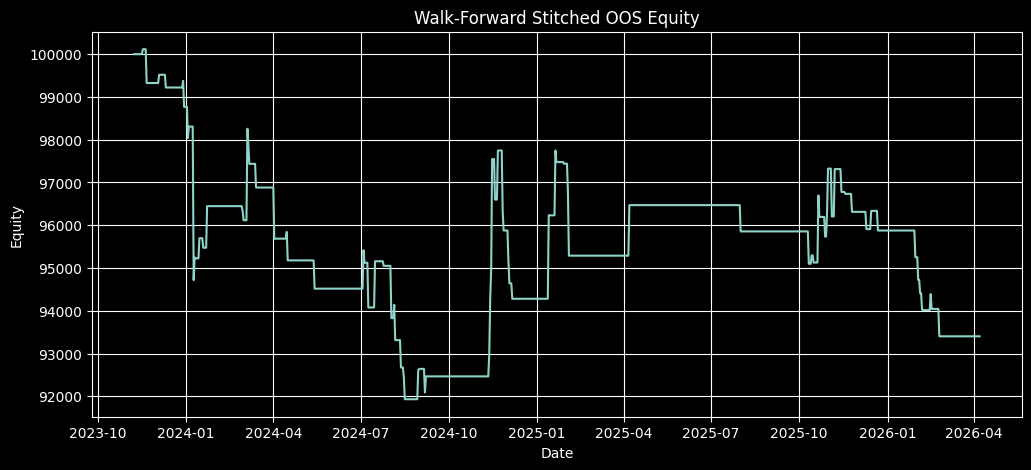

In [27]:
eq = wfa_result["stitched_oos_equity"]

if not eq.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(eq.index, eq["equity"])
    plt.title("Walk-Forward Stitched OOS Equity")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

# просмотр OOS результатов по окнам

In [28]:
cols = [
    "window_id",
    "train_start", "train_end",
    "test_start", "test_end",
    "is_return_pct", "oos_return_pct",
    "is_pf", "oos_pf",
    "oos_n_trades"
]

wfa_result["windows_df"][cols]

,window_id,train_start,train_end,test_start,test_end,is_return_pct,oos_return_pct,is_pf,oos_pf,oos_n_trades
0,1,2023-06-08,2023-11-08,2023-11-08,2023-12-08,4.962082,-0.481980,4.551194,0.390380,3
1,2,2023-07-08,2023-12-08,2023-12-08,2024-01-08,1.804631,-1.217169,2.536857,0.266213,4
2,3,2023-08-08,2024-01-08,2024-01-08,2024-02-08,1.674499,-1.892150,1.550654,0.576447,7
3,4,2023-09-08,2024-02-08,2024-02-08,2024-03-08,2.131867,1.025179,2.379212,1.785147,4
4,5,2023-10-08,2024-03-08,2024-03-08,2024-04-08,4.108534,-1.794668,23.250755,0.000000,3
5,6,2023-11-08,2024-04-08,2024-04-08,2024-05-08,3.170620,-0.530857,25.256622,0.000000,1
6,7,2023-12-08,2024-05-08,2024-05-08,2024-06-08,6.175754,-0.694332,1.522949,0.000000,1
7,8,2024-01-08,2024-06-08,2024-06-08,2024-07-08,7.094622,0.641548,2.499862,3.095214,2
8,9,2024-02-08,2024-07-08,2024-07-08,2024-08-08,10.376941,-1.843498,2.152447,0.531596,9
9,10,2024-03-08,2024-08-08,2024-08-08,2024-09-08,15.140221,-0.908449,3.369823,0.602207,5


# Просмотр всех OOS сделок

In [29]:
wfa_result["all_oos_trades_df"].head(20)

,entry_time,exit_time,size,price_in,price_out,pnl_gross,pnl_net,barlen,window_id
0,2023-11-17 00:45:00,2023-11-17 05:00:00,0.0,36349.898526,36349.898526,182.951789,115.108808,17,1
1,2023-11-21 17:00:00,2023-11-21 18:00:00,0.0,37202.238960,37202.238960,-721.144327,-790.623420,4,1
2,2023-12-04 18:30:00,2023-12-04 21:30:00,0.0,41673.292992,41673.292992,270.343918,193.534958,12,1
3,2023-12-11 07:15:00,2023-12-11 13:30:00,0.0,42270.952500,42270.952500,-243.484214,-299.335090,25,2
4,2023-12-29 23:30:00,2023-12-30 03:30:00,0.0,41983.885098,41983.885098,-375.327677,-454.454114,16,2
5,2024-01-03 16:00:00,2024-01-03 19:00:00,0.0,43008.610002,43008.610002,-866.162525,-904.960086,12,2
6,2024-01-03 19:30:00,2024-01-04 07:15:00,0.0,42682.084710,42682.084710,481.990025,441.580089,47,2
7,2024-01-09 21:15:00,2024-01-09 21:30:00,0.0,47923.832850,47923.832850,-3584.475583,-3650.304967,1,3
8,2024-01-10 02:30:00,2024-01-10 07:45:00,0.0,46080.000000,46080.000000,-498.743002,-570.594185,21,3
9,2024-01-10 16:00:00,2024-01-10 18:00:00,0.0,45555.499278,45555.499278,1158.508597,1107.607812,8,3
